In [1]:
# ============================================
# Red Wine Quality - KMeans Clustering + NLP
# Jupyter Notebook Code
# ============================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.feature_extraction.text import TfidfVectorizer

# Optional warning control
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 2. Load dataset
df = pd.read_csv("RedWineQuality.csv")

# Show first 5 rows
df.head()

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
1,7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
2,7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
3,11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...
4,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5


In [3]:
# 3. Basic dataset info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (1599, 1)

Columns:
 Index(['fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"'], dtype='str')

Missing values:
 fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"    0
dtype: int64

Data types:
 fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"    str
dtype: object


In [4]:
# 4. Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()

,"fixed_acidity;""volatile_acidity"";""citric_acid"";""residual_sugar"";""chlorides"";""free_sulfur_dioxide"";""total_sulfur_dioxide"";""density"";""ph"";""sulphates"";""alcohol"";""quality"""
0,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
1,7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
2,7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
3,11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...
4,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5


In [5]:
# 5. Quick statistical summary
df.describe()

,"fixed_acidity;""volatile_acidity"";""citric_acid"";""residual_sugar"";""chlorides"";""free_sulfur_dioxide"";""total_sulfur_dioxide"";""density"";""ph"";""sulphates"";""alcohol"";""quality"""
count,1599
unique,1359
top,7.2;0.36;0.46;2.1;0.074;24;44;0.99534;3.4;0.85...
freq,4


In [7]:
print(df.head())
print(df.dtypes)

  fixed_acidity;"volatile_acidity";"citric_acid";"residual_sugar";"chlorides";"free_sulfur_dioxide";"total_sulfur_dioxide";"density";"ph";"sulphates";"alcohol";"quality"
0   7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5                                                                                                                     
1   7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5                                                                                                                     
2  7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...                                                                                                                     
3  11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...                                                                                                                     
4   7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5                                                                                                  

In [8]:
df.corr(numeric_only=True)

""


In [9]:
# 7. Select numeric features
# If quality exists, exclude it from clustering input
if 'quality' in df.columns:
    X = df.drop('quality', axis=1)
else:
    X = df.copy()

X.head()

,"fixed_acidity;""volatile_acidity"";""citric_acid"";""residual_sugar"";""chlorides"";""free_sulfur_dioxide"";""total_sulfur_dioxide"";""density"";""ph"";""sulphates"";""alcohol"";""quality"""
0,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
1,7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
2,7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
3,11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...
4,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5


In [13]:
df = df.iloc[:, 0].str.split(';', expand=True)
df = df.astype(float)

In [19]:
print(df.head())
print(df.dtypes)

     0     1     2    3      4     5     6       7     8     9    10   11
0   7.4  0.70  0.00  1.9  0.076  11.0  34.0  0.9978  3.51  0.56  9.4  5.0
1   7.8  0.88  0.00  2.6  0.098  25.0  67.0  0.9968  3.20  0.68  9.8  5.0
2   7.8  0.76  0.04  2.3  0.092  15.0  54.0  0.9970  3.26  0.65  9.8  5.0
3  11.2  0.28  0.56  1.9  0.075  17.0  60.0  0.9980  3.16  0.58  9.8  6.0
4   7.4  0.70  0.00  1.9  0.076  11.0  34.0  0.9978  3.51  0.56  9.4  5.0
0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
dtype: object


In [22]:
print(df.head())
print(df.dtypes)

     0     1     2    3      4     5     6       7     8     9    10   11
0   7.4  0.70  0.00  1.9  0.076  11.0  34.0  0.9978  3.51  0.56  9.4  5.0
1   7.8  0.88  0.00  2.6  0.098  25.0  67.0  0.9968  3.20  0.68  9.8  5.0
2   7.8  0.76  0.04  2.3  0.092  15.0  54.0  0.9970  3.26  0.65  9.8  5.0
3  11.2  0.28  0.56  1.9  0.075  17.0  60.0  0.9980  3.16  0.58  9.8  6.0
4   7.4  0.70  0.00  1.9  0.076  11.0  34.0  0.9978  3.51  0.56  9.4  5.0
0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
dtype: object


In [24]:


df.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


In [27]:
# 15. Convert each row into a text sentence
def row_to_text(row):
    text = (
        f"fixed acidity {row.get('fixed_acidity', '')} "
        f"volatile acidity {row.get('volatile_acidity', '')} "
        f"citric acid {row.get('citric_acid', '')} "
        f"residual sugar {row.get('residual_sugar', '')} "
        f"chlorides {row.get('chlorides', '')} "
        f"free sulfur dioxide {row.get('free_sulfur_dioxide', '')} "
        f"total sulfur dioxide {row.get('total_sulfur_dioxide', '')} "
        f"density {row.get('density', '')} "
        f"pH {row.get('ph', '')} "
        f"sulphates {row.get('sulphates', '')} "
        f"alcohol {row.get('alcohol', '')} "
    )
    
    if 'quality' in row.index:
        text += f"quality {row['quality']}"
        
    return text

df['text_description'] = df.apply(row_to_text, axis=1)
df[['text_description']].head()

,text_description
0,fixed acidity volatile acidity citric acid ...
1,fixed acidity volatile acidity citric acid ...
2,fixed acidity volatile acidity citric acid ...
3,fixed acidity volatile acidity citric acid ...
4,fixed acidity volatile acidity citric acid ...


In [28]:
# 16. TF-IDF vectorization
vectorizer = TfidfVectorizer(stop_words='english')
X_text = vectorizer.fit_transform(df['text_description'])

print("TF-IDF shape:", X_text.shape)

TF-IDF shape: (1599, 16)


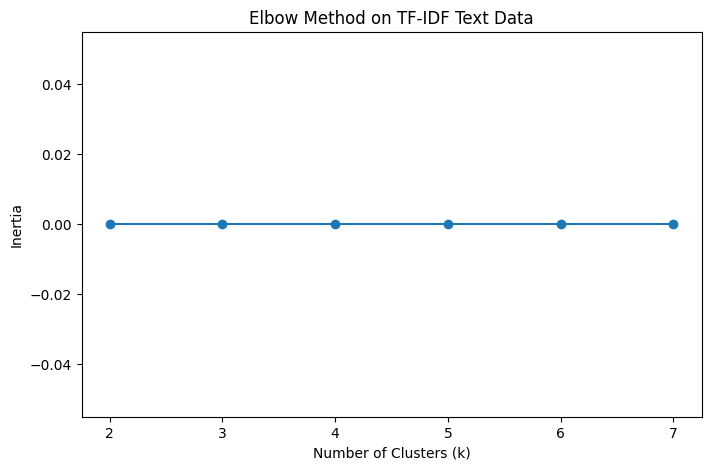

In [29]:
# 17. Elbow-like check for text clustering
text_inertia = []
text_k_values = range(2, 8)

for k in text_k_values:
    km_text = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_text.fit(X_text)
    text_inertia.append(km_text.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(text_k_values, text_inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method on TF-IDF Text Data")
plt.show()

In [30]:
# 18. Final NLP-based KMeans
text_k = 3  # change if needed
kmeans_text = KMeans(n_clusters=text_k, random_state=42, n_init=10)
df['text_cluster'] = kmeans_text.fit_predict(X_text)

df[['text_description', 'text_cluster']].head()

,text_description,text_cluster
0,fixed acidity volatile acidity citric acid ...,0
1,fixed acidity volatile acidity citric acid ...,0
2,fixed acidity volatile acidity citric acid ...,0
3,fixed acidity volatile acidity citric acid ...,0
4,fixed acidity volatile acidity citric acid ...,0


In [31]:
# 19. Top terms in each NLP cluster
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans_text.cluster_centers_.argsort()[:, ::-1]

for i in range(text_k):
    print(f"\nTop words in text cluster {i}:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_words))


Top words in text cluster 0:
sulfur, dioxide, acidity, volatile, total, sulphates, sugar, residual, ph, free

Top words in text cluster 1:
sulfur, dioxide, acidity, volatile, total, sulphates, sugar, residual, ph, free

Top words in text cluster 2:
sulfur, dioxide, acidity, volatile, total, sulphates, sugar, residual, ph, free


In [34]:
import pandas as pd
from sklearn.cluster import KMeans

# 1. Clean column names
df.columns = df.columns.str.strip()

# 2. Check columns
print("Columns in DataFrame:", df.columns.tolist())

# 3. Create numeric clusters (REQUIRED if missing)
# Replace 'feature1', 'feature2', etc. with your actual numeric columns
numeric_features = df.select_dtypes(include=['int64', 'float64'])

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(numeric_features)

# 4. Check text_cluster exists
if 'text_cluster' not in df.columns:
    raise KeyError("Column 'text_cluster' not found in DataFrame")

# 5. Crosstab comparison
crosstab = pd.crosstab(df['cluster'], df['text_cluster'])

# 6. Display result
print(crosstab)

Columns in DataFrame: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 'text_description', 'text_cluster']
text_cluster    0
cluster          
0             854
1             505
2             240
